# Exploração de dados de Forex via MT5

Pré-requisito: terminal MetaTrader 5 instalado e logado (ver `README.md` na raiz do projeto).

In [1]:
import sys
from datetime import datetime
import pandas as pd
import numpy as np
import pytz

import MetaTrader5 as mt5
import matplotlib.pyplot as plt

sys.path.append("..")
import mt5_data

# Carregar: Five Percent Online MT5

## Configuração: pares, timeframes e período

In [2]:
mt5_data.init()

In [3]:
CURRENCY_PAIRS = ["EURUSD", "GBPUSD", "USDJPY", "AUDNZD", "AUDJPY", "AUDCHF", "USDBRL"]
INDICES = ["NAS100", "US30", "SP500", "JPN225", "DAX40", "ASXAUD", "IBXEUR"]
COMMODITIES = ["XAUUSD", "CUCUSD", "BTCUSD", "XBRUSD"]

TIMEFRAMES = {
    "M5": mt5.TIMEFRAME_M5,
    "M15": mt5.TIMEFRAME_M15,
    "M30": mt5.TIMEFRAME_M30,
    "H1": mt5.TIMEFRAME_H1,
    "H2": mt5.TIMEFRAME_H2,
    "H4": mt5.TIMEFRAME_H4,
    "H12": mt5.TIMEFRAME_H12,
    "D1": mt5.TIMEFRAME_D1
}

timezone = pytz.timezone('Etc/UTC')

## Coleta dos dados

Resultado: dicionário `data[symbol][timeframe_label] -> DataFrame`.

In [111]:
# LIMITES DA API:
"""
H1: Desde 2020 (6 anos)
M30: Desde 2022 (4 anos)
M15: Desde 2024 (2 anos)
"""
# Teste com único ativo
asset = 'AUDCHF'
tf = 'M30'

year = 2022 if tf == 'M30' else 2020

START = datetime(year, 1, 1, tzinfo=timezone)
END = datetime(2026, 9, 18, tzinfo=timezone)

mt5_tf = TIMEFRAMES[tf]

try:
    # Checks whether file is already downloaded
    df_asset = pd.read_csv(f'import\\{asset}_{tf}.csv')
except:
    df_asset = mt5_data.get_rates_df(asset, mt5_tf, START, END)
    df_asset.to_csv(f'import/{asset}_{tf}.csv', index=False)

## Mean reversion: médias móveis simples (21 e 88)

In [112]:
df_asset['sma_21'] = df_asset['close'].rolling(21).mean()
df_asset['sma_88'] = df_asset['close'].rolling(88).mean()

1. diff() dá a variação de close entre barras.
2. clip separa ganhos (valores positivos) de perdas (valores negativos, invertidos para positivo).
3. ewm(alpha=1/period, adjust=False) reproduz a suavização de Wilder (a fórmula original do RSI) — é diferente de uma média móvel simples (rolling().mean()), que também funciona mas não é o RSI "clássico". Para period=2 essa diferença já é perceptível.
4. rs é a razão ganho médio/perda médio; a fórmula final normaliza isso entre 0 e 100.

In [113]:
# Incrementando com RSI
rsi_period = 2

delta = df_asset['close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.ewm(alpha=1/rsi_period, adjust=False).mean()
avg_loss = loss.ewm(alpha=1/rsi_period, adjust=False).mean()

rs = avg_gain / avg_loss
df_asset['rsi_2'] = (100 - (100 / (1 + rs))).round(2)

In [114]:
# Tendência geral (SMA longa > SMA curta)
df_asset['trend'] = (df_asset['sma_21'] > df_asset['sma_88']).astype(int)

# Sinalizar overbuy e oversell
rsi_overbought = 80
rsi_oversold = 20
df_asset['overbought'] = (df_asset['rsi_2'] > rsi_overbought).astype(int)
df_asset['oversold'] = (df_asset['rsi_2'] < rsi_oversold).astype(int)

In [115]:
# Consecutive-run counters: increment while the flag is 1, reset to 0 the moment it drops to 0
overbought = df_asset['overbought']
run_id = (overbought != overbought.shift()).cumsum()
df_asset['overbuy_seq'] = overbought.groupby(run_id).cumsum()

oversold = df_asset['oversold']
run_id = (oversold != oversold.shift()).cumsum()
df_asset['oversell_seq'] = oversold.groupby(run_id).cumsum()

In [116]:
# Check if the trend is being followed by the overbought/oversold signals
# Trend (1) => long | Trend(0) -> short
df_asset['follows_trend'] = ((df_asset['trend'] == 1) & (df_asset['oversold'] == 1)) | ((df_asset['trend'] == 0) & (df_asset['overbought'] == 1))

In [117]:
# Check price variation (in pct) for next candles
for i in range(0, 13):
    df_asset[f'next_{i+1}_pct'] = (df_asset['close'].shift(-i-1) / df_asset['close'] - 1).round(6) * 100

In [118]:
# # Analítico rápido geral
# cols = ['time', 'open', 'close', 'rsi_2', 'trend', 'overbuy_seq', 'oversell_seq', 'follows_trend','next_1_pct', 'next_2_pct', 'next_3_pct', 'next_4_pct', 'next_5_pct', 'next_6_pct', 'next_7_pct', 'next_8_pct', 'next_9_pct', 'next_10_pct', 'next_11_pct', 'next_12_pct']

# i = 600
# df_asset[cols][i:i+20]

# # df_asset[88:88+30]

In [119]:
# C_1 = Acionou gatilho de overbuy/oversell e seguiu a tendência
c_1 = (df_asset['follows_trend']==True) & ((df_asset['overbuy_seq']>0) | (df_asset['oversell_seq']>0))

# Normalizar resultados (Porcentagens de acordo com direção da tendência)
cols_pct = [col for col in df_asset.columns if col.startswith('next_')]

for col in cols_pct:
    num = col.split('_')[1]
    df_asset[f'next_{num}_pct_return'] = np.where(df_asset['trend'] == 0, df_asset[col] * (-1), df_asset[col])

In [120]:
# # 'open', 
# cols = ['time', 'close', 'rsi_2', 'trend', 'overbuy_seq', 'oversell_seq', 'follows_trend', 'next_1_pct_return',  'next_2_pct_return',  'next_3_pct_return',  'next_4_pct_return',  'next_5_pct_return',  'next_6_pct_return',  'next_7_pct_return',  'next_8_pct_return',  'next_9_pct_return',  'next_10_pct_return',  'next_11_pct_return',  'next_12_pct_return',  'next_13_pct_return']

# i = 600
# df_asset[cols[:-8]][i:i+20]

In [121]:
# Backup
piriri = df_asset.copy()

# Signal frequency

In [122]:
total_overbuy = df_asset.groupby('overbuy_seq').count()[['close']].reset_index().rename(columns={'overbuy_seq': 'sequence', 'close': 'OB_seq'})
total_oversell = df_asset.groupby('oversell_seq').count()[['close']].reset_index().rename(columns={'oversell_seq': 'sequence', 'close': 'OS_seq'})
overbuy_on_trend = df_asset[df_asset['follows_trend']].groupby('overbuy_seq').count()[['close']].reset_index().rename(columns={'overbuy_seq': 'sequence', 'close': 'OB_OT_seq'})
oversell_on_trend = df_asset[df_asset['follows_trend']].groupby('oversell_seq').count()[['close']].reset_index().rename(columns={'oversell_seq': 'sequence', 'close': 'OS_OT_seq'})

i_cols = [0, 1, 3, 5, 7]

df_freq = pd.concat([total_overbuy, total_oversell, overbuy_on_trend, oversell_on_trend], axis=1)
df_freq = df_freq.iloc[:, i_cols].fillna(0).astype(int)
df_freq['candles_on_strategy'] = df_freq['OB_OT_seq'] + df_freq['OS_OT_seq']
df_freq.loc[df_freq['sequence']==0, 'candles_on_strategy'] = 0
df_freq['candles (%)'] = (df_freq['candles_on_strategy'] / np.sum(df_freq['candles_on_strategy'])).round(3) * 100
df_freq['cumulative_pct'] = df_freq['candles (%)'].cumsum()
df_freq[['sequence', 'candles_on_strategy', 'candles (%)', 'cumulative_pct']]

,sequence,candles_on_strategy,candles (%),cumulative_pct
0,0,0,0.0,0.0
1,1,6476,49.7,49.7
2,2,3178,24.4,74.1
3,3,1577,12.1,86.2
4,4,860,6.6,92.8
5,5,472,3.6,96.4
6,6,242,1.9,98.3
7,7,123,0.9,99.2
8,8,61,0.5,99.7
9,9,26,0.2,99.9


In [123]:
# Max frequency for analysis
max_seq = 6

In [124]:
cols = ['time', 'close', 'rsi_2', 'trend', 'overbuy_seq', 'oversell_seq', 'follows_trend', 'next_1_pct_return',  'next_2_pct_return',  'next_3_pct_return',  'next_4_pct_return',  'next_5_pct_return',  'next_6_pct_return',  'next_7_pct_return',  'next_8_pct_return',  'next_9_pct_return',  'next_10_pct_return',  'next_11_pct_return',  'next_12_pct_return',  'next_13_pct_return']

# AGG - RETORNO MÉDIO POR SEQUÊNCIA DE OVERBUY/OVERSELL
cols_analise = cols[-16:]

# DF somente com trades da estratégia
df_trades = df_asset[c_1].copy()

# DF agregando trades por sequência de overbuy
agg_df_OB_trades = df_trades[cols_analise].groupby('overbuy_seq').agg(['mean', 'std'])#.reset_index()
agg_df_OB_trades.drop(columns=['oversell_seq', 'follows_trend'], inplace=True)

# DF agregando trades por sequência de oversell
agg_df_OS_trades = df_trades[cols_analise].groupby('oversell_seq').agg(['mean', 'std'])#.reset_index()
agg_df_OS_trades.drop(columns=['overbuy_seq', 'follows_trend'], inplace=True)

# Removing outlier columns
agg_df_OB_trades = agg_df_OB_trades[1:max_seq+1]
agg_df_OS_trades = agg_df_OS_trades[1:max_seq+1]

In [125]:
# OVERBUY
# Quantos desvios-padrão a média representa (mean / std) — sinal vs. ruído por cenário
return_cols = agg_df_OB_trades.columns.get_level_values(0).unique()
for col in return_cols:
    agg_df_OB_trades.loc[:, (col, 'n_std')] = agg_df_OB_trades[(col, 'mean')] / agg_df_OB_trades[(col, 'std')]

# OVERSELL
# Quantos desvios-padrão a média representa (mean / std) — sinal vs. ruído por cenário
return_cols = agg_df_OS_trades.columns.get_level_values(0).unique()
for col in return_cols:
    agg_df_OS_trades.loc[:, (col, 'n_std')] = agg_df_OS_trades[(col, 'mean')] / agg_df_OS_trades[(col, 'std')]

# Retornos por Overbuy e Oversell

In [126]:
# Retornos de OB e OS combinados
OVERBUY_RETURNS = agg_df_OB_trades.xs('mean', level=1, axis=1).reset_index()
OVERSELL_RETURNS = agg_df_OS_trades.xs('mean', level=1, axis=1).reset_index()

OVERBUY_RETURNS.rename(columns={'overbuy_seq': 'seq'}, inplace=True)
OVERSELL_RETURNS.rename(columns={'oversell_seq': 'seq'}, inplace=True)

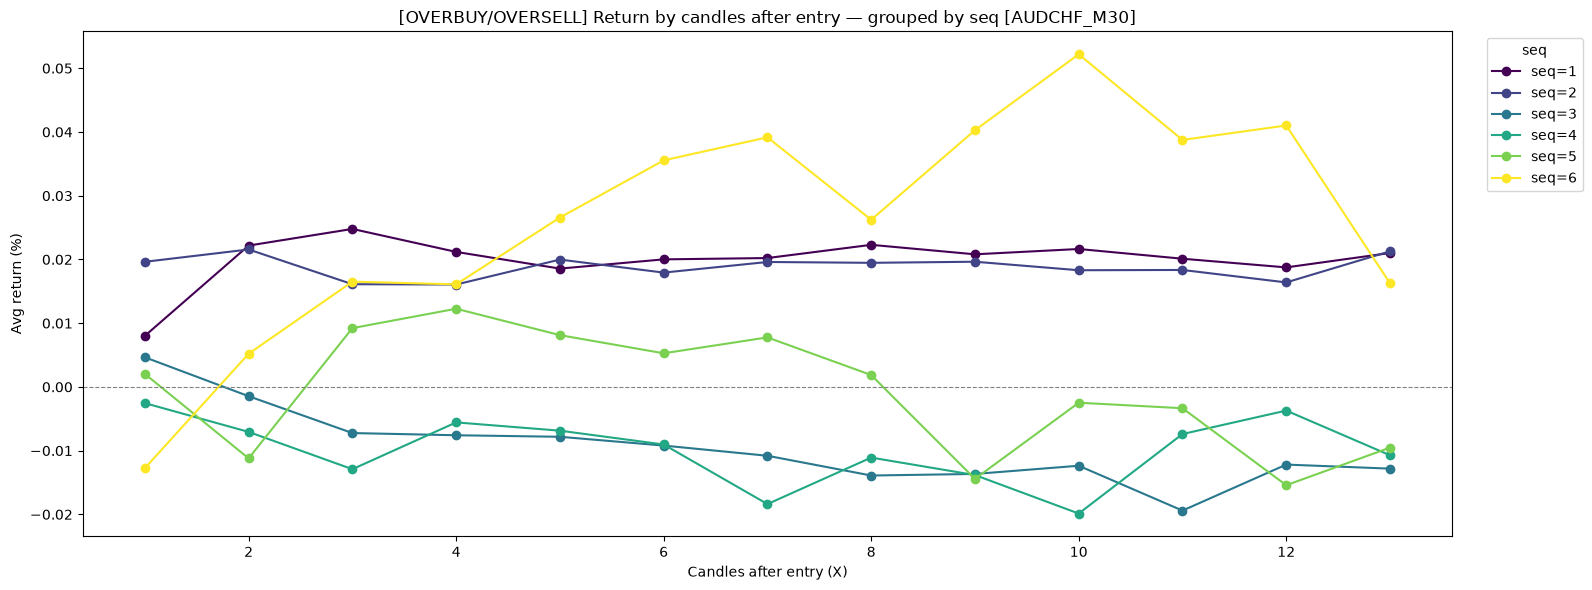

In [127]:
# Soma OVERBUY_RETURNS + OVERSELL_RETURNS por seq (todas as colunas exceto 'seq')
pct_cols = [c for c in OVERBUY_RETURNS.columns if c != 'seq']

COMBINED_RETURNS = OVERBUY_RETURNS.merge(OVERSELL_RETURNS, on='seq', suffixes=('_OB', '_OS'))
for col in pct_cols:
    COMBINED_RETURNS[col] = COMBINED_RETURNS[f'{col}_OB'] + COMBINED_RETURNS[f'{col}_OS']
COMBINED_RETURNS = COMBINED_RETURNS[['seq'] + pct_cols]

###

# Line plot: avg return (%) by candles-after-entry, one curve per overbuy_seq value
pct_cols = sorted(
    [c for c in COMBINED_RETURNS.columns if c.startswith('next_') and c.endswith('_pct_return')],
    key=lambda c: int(c.split('_')[1])
)
x_values = [int(c.split('_')[1]) for c in pct_cols]

fig, ax = plt.subplots(figsize=(16, 6))
cmap = plt.cm.viridis
norm = plt.Normalize(COMBINED_RETURNS['seq'].min(), COMBINED_RETURNS['seq'].max())

for _, row in COMBINED_RETURNS.iterrows():
    y_values = row[pct_cols].values
    ax.plot(x_values, y_values, marker='o', color=cmap(norm(row['seq'])), label=f"seq={int(row['seq'])}")

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Candles after entry (X)')
ax.set_ylabel('Avg return (%)')
ax.set_title(f'[OVERBUY/OVERSELL] Return by candles after entry — grouped by seq [{asset}_{tf}]')
ax.legend(title='seq', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [128]:
# retornos_OB = agg_df_OB_trades.xs('mean', level=1, axis=1).reset_index()

# # Line plot: avg return (%) by candles-after-entry, one curve per overbuy_seq value
# pct_cols = sorted(
#     [c for c in retornos_OB.columns if c.startswith('next_') and c.endswith('_pct_return')],
#     key=lambda c: int(c.split('_')[1])
# )
# x_values = [int(c.split('_')[1]) for c in pct_cols]

# fig, ax = plt.subplots(figsize=(12, 6))
# cmap = plt.cm.viridis
# norm = plt.Normalize(retornos_OB['overbuy_seq'].min(), retornos_OB['overbuy_seq'].max())

# for _, row in retornos_OB.iterrows():
#     y_values = row[pct_cols].values
#     ax.plot(x_values, y_values, marker='o', color=cmap(norm(row['overbuy_seq'])), label=f"seq={int(row['overbuy_seq'])}")

# ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
# ax.set_xlabel('Candles after entry (X)')
# ax.set_ylabel('Avg return (%)')
# ax.set_title(f'[OVERBUY] Return by candles after entry — grouped by overbuy_seq [{asset}_{tf}]')
# ax.legend(title='overbuy_seq', bbox_to_anchor=(1.02, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

In [129]:
# retornos_OS = agg_df_OS_trades.xs('mean', level=1, axis=1).reset_index()

# # Line plot: avg return (%) by candles-after-entry, one curve per oversell_seq value
# pct_cols = sorted(
#     [c for c in retornos_OS.columns if c.startswith('next_') and c.endswith('_pct_return')],
#     key=lambda c: int(c.split('_')[1])
# )
# x_values = [int(c.split('_')[1]) for c in pct_cols]

# fig, ax = plt.subplots(figsize=(12, 6))
# cmap = plt.cm.viridis
# norm = plt.Normalize(retornos_OS['oversell_seq'].min(), retornos_OS['oversell_seq'].max())

# for _, row in retornos_OS.iterrows():
#     y_values = row[pct_cols].values
#     ax.plot(x_values, y_values, marker='o', color=cmap(norm(row['oversell_seq'])), label=f"seq={int(row['oversell_seq'])}")

# ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
# ax.set_xlabel('Candles after entry (X)')
# ax.set_ylabel('Avg return (%)')
# ax.set_title(f'[OVERSELL] Return by candles after entry — grouped by oversell_seq [{asset}_{tf}]')
# ax.legend(title='oversell_seq', bbox_to_anchor=(1.02, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

# Desvio-padrão dos retornos

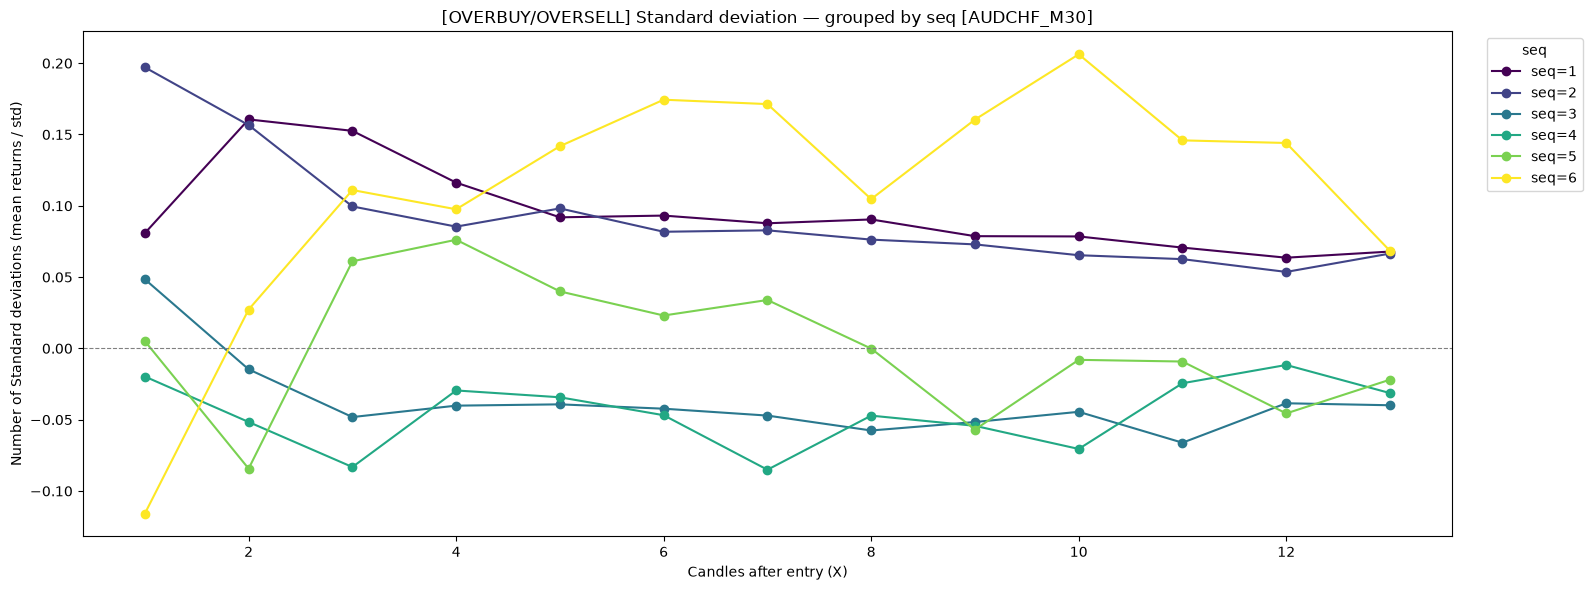

In [130]:
# Retornos de OB e OS combinados
OVERBUY_STD = agg_df_OB_trades.xs('n_std', level=1, axis=1).reset_index()
OVERSELL_STD = agg_df_OS_trades.xs('n_std', level=1, axis=1).reset_index()

OVERBUY_STD.rename(columns={'overbuy_seq': 'seq'}, inplace=True)
OVERSELL_STD.rename(columns={'oversell_seq': 'seq'}, inplace=True)

# Soma OVERBUY_STD + OVERSELL_STD por seq (todas as colunas exceto 'seq')
pct_cols = [c for c in OVERBUY_STD.columns if c != 'seq']

COMBINED_STD = OVERBUY_STD.merge(OVERSELL_STD, on='seq', suffixes=('_OB', '_OS'))
for col in pct_cols:
    COMBINED_STD[col] = COMBINED_STD[f'{col}_OB'] + COMBINED_STD[f'{col}_OS']
COMBINED_STD = COMBINED_STD[['seq'] + pct_cols]

###

# Line plot: avg return (%) by candles-after-entry, one curve per seq value
pct_cols = sorted(
    [c for c in COMBINED_STD.columns if c.startswith('next_') and c.endswith('_pct_return')],
    key=lambda c: int(c.split('_')[1])
)
x_values = [int(c.split('_')[1]) for c in pct_cols]

fig, ax = plt.subplots(figsize=(16, 6))
cmap = plt.cm.viridis
norm = plt.Normalize(COMBINED_STD['seq'].min(), COMBINED_STD['seq'].max())

for _, row in COMBINED_STD.iterrows():
    y_values = row[pct_cols].values
    ax.plot(x_values, y_values, marker='o', color=cmap(norm(row['seq'])), label=f"seq={int(row['seq'])}")

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Candles after entry (X)')
ax.set_ylabel('Number of Standard deviations (mean returns / std)')
ax.set_title(f'[OVERBUY/OVERSELL] Standard deviation — grouped by seq [{asset}_{tf}]')
ax.legend(title='seq', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [131]:
# std_OB = agg_df_OB_trades.xs('n_std', level=1, axis=1).reset_index()

# # Line plot: avg return (%) by candles-after-entry, one curve per overbuy_seq value
# pct_cols = sorted(
#     [c for c in std_OB.columns if c.startswith('next_') and c.endswith('_pct_return')],
#     key=lambda c: int(c.split('_')[1])
# )
# x_values = [int(c.split('_')[1]) for c in pct_cols]

# fig, ax = plt.subplots(figsize=(12, 6))
# cmap = plt.cm.viridis
# norm = plt.Normalize(std_OB['overbuy_seq'].min(), std_OB['overbuy_seq'].max())

# for _, row in std_OB.iterrows():
#     y_values = row[pct_cols].values
#     ax.plot(x_values, y_values, marker='o', color=cmap(norm(row['overbuy_seq'])), label=f"seq={int(row['overbuy_seq'])}")

# ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
# ax.set_xlabel('Candles after entry (X)')
# ax.set_ylabel('Number of Standard deviations (mean returns / std)')
# ax.set_title(f'[OVERBUY] Standard deviation — grouped by overbuy_seq [{asset}_{tf}]')
# ax.legend(title='overbuy_seq', bbox_to_anchor=(1.02, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

In [132]:
# std_OS = agg_df_OS_trades.xs('n_std', level=1, axis=1).reset_index()

# # Line plot: avg return (%) by candles-after-entry, one curve per oversell_seq value
# pct_cols = sorted(
#     [c for c in std_OS.columns if c.startswith('next_') and c.endswith('_pct_return')],
#     key=lambda c: int(c.split('_')[1])
# )
# x_values = [int(c.split('_')[1]) for c in pct_cols]

# fig, ax = plt.subplots(figsize=(12, 6))
# cmap = plt.cm.viridis
# norm = plt.Normalize(std_OS['oversell_seq'].min(), std_OS['oversell_seq'].max())

# for _, row in std_OS.iterrows():
#     y_values = row[pct_cols].values
#     ax.plot(x_values, y_values, marker='o', color=cmap(norm(row['oversell_seq'])), label=f"seq={int(row['oversell_seq'])}")

# ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
# ax.set_xlabel('Candles after entry (X)')
# ax.set_ylabel('Number of Standard deviations (mean returns / std)')
# ax.set_title(f'[OVERSELL] Standard deviation — grouped by oversell_seq [{asset}_{tf}]')
# ax.legend(title='oversell_seq', bbox_to_anchor=(1.02, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

# Pretest da estratégia

In [133]:
# Parâmetros já descobertos:
"""
- EURUSD (H1): num_seq=2, num_candles_exit=3
- EURUSD (M30): num_seq=2, num_candles_exit=5
- EURUSD (M15): num_seq=2, num_candles_exit=2
- GBPUSD (M30): num_seq=2, num_candles_exit=6
- AUDJPY (M30): num_seq=1, num_candles_exit=7
- AUDCHF (M30): num_seq=1, num_candles_exit=7
- NAS100 (M30): num_seq=3, num_candles_exit=2

"""

'\n- EURUSD (H1): num_seq=2, num_candles_exit=3\n- EURUSD (M30): num_seq=2, num_candles_exit=5\n- EURUSD (M15): num_seq=2, num_candles_exit=2\n- GBPUSD (M30): num_seq=2, num_candles_exit=6\n- AUDJPY (M30): num_seq=1, num_candles_exit=7\n- AUDCHF (M30): num_seq=1, num_candles_exit=7\n- NAS100 (M30): num_seq=3, num_candles_exit=2\n\n'

In [142]:
# num_seq = define C_1 ==> Qtd de sequências de OB/OS da estratégia (entry signal) que foram acionadas e seguiram a tendência
# num_candles_exit = define C_2 ==> Qtd de candles para saída do trade (exit signal)

num_seq = 1
num_candles_exit = 7

In [143]:
# Calculate returns from given parameters
all_cols = ['time', 'open', 'high', 'low', 'close', 'tick_volume', 'spread',
       'real_volume', 'sma_21', 'sma_88', 'rsi_2', 'trend', 'overbought',
       'oversold', 'overbuy_seq', 'oversell_seq', 'follows_trend',
       'next_1_pct', 'next_2_pct', 'next_3_pct', 'next_4_pct', 'next_5_pct',
       'next_6_pct', 'next_7_pct', 'next_8_pct', 'next_9_pct', 'next_10_pct',
       'next_11_pct', 'next_12_pct', 'next_13_pct', 'next_1_pct_return',
       'next_2_pct_return', 'next_3_pct_return', 'next_4_pct_return',
       'next_5_pct_return', 'next_6_pct_return', 'next_7_pct_return',
       'next_8_pct_return', 'next_9_pct_return', 'next_10_pct_return',
       'next_11_pct_return', 'next_12_pct_return', 'next_13_pct_return']

cols_graphs = ['time', 'trend', 'overbought',
       'oversold', 'overbuy_seq', 'oversell_seq', 'follows_trend',
       'next_1_pct', 'next_2_pct', 'next_3_pct', 'next_4_pct', 'next_5_pct',
       'next_6_pct', 'next_7_pct', 'next_8_pct', 'next_9_pct', 'next_10_pct',
       'next_11_pct', 'next_12_pct', 'next_13_pct', 'next_1_pct_return',
       'next_2_pct_return', 'next_3_pct_return', 'next_4_pct_return',
       'next_5_pct_return', 'next_6_pct_return', 'next_7_pct_return',
       'next_8_pct_return', 'next_9_pct_return', 'next_10_pct_return',
       'next_11_pct_return', 'next_12_pct_return', 'next_13_pct_return']

# C_1 => Qtd de sequências de OB/OS da estratégia (entry signal) que foram acionadas e seguiram a tendência
c_1 = (df_trades[f'overbuy_seq'] == num_seq) | (df_trades[f'oversell_seq'] == num_seq)

# C_2 => Qtd de candles para saída do trade (exit signal)
c_2 = df_trades[f'next_{num_candles_exit}_pct_return']

cols_simulation = ['time', 'trend', 'follows_trend', f'next_{num_candles_exit}_pct_return', f'next_{num_candles_exit}_pct']

df_sim = df_trades.loc[c_1 & c_2, cols_simulation].copy()

df_sim['month'] = pd.to_datetime(df_sim['time']).dt.strftime('%Y-%m')

def calculate_returns(since_period, to_period, grouping=True):

       df = df_sim.loc[(df_sim['month']>=since_period) & (df_sim['month']<=to_period), :]

       if grouping:

              df.drop(['time'], inplace=True, axis=1)

              # Grouping by month and summing the returns for each month
              agg_df_sim = df.groupby('month').sum().reset_index()
              agg_df_sim['asset_variation'] = agg_df_sim[f'next_{num_candles_exit}_pct'].cumsum()
              agg_df_sim['cumulative_return'] = agg_df_sim[f'next_{num_candles_exit}_pct_return'].cumsum()

              return agg_df_sim

       # No grouping, the cumulative return is calculated by summing the returns for each month. This gives a clear picture of how the strategy performed over time, allowing for an analysis of trends and performance metrics. The asset variation provides insight into how the underlying asset's price changed over the same period, which can be useful for comparing the strategy's performance against market movements.
       df['asset_variation'] = df[f'next_{num_candles_exit}_pct'].cumsum()
       df['cumulative_return'] = df[f'next_{num_candles_exit}_pct_return'].cumsum()

       return df

In [144]:
period_from = '2026-01'
period_to = '2026-09'
group_data = False
print(f'Data available from: {START.strftime("%Y-%m")}')
print(f'- {asset} ({tf}): num_seq={num_seq}, num_candles_exit={num_candles_exit}')

Data available from: 2022-01
- AUDCHF (M30): num_seq=1, num_candles_exit=7


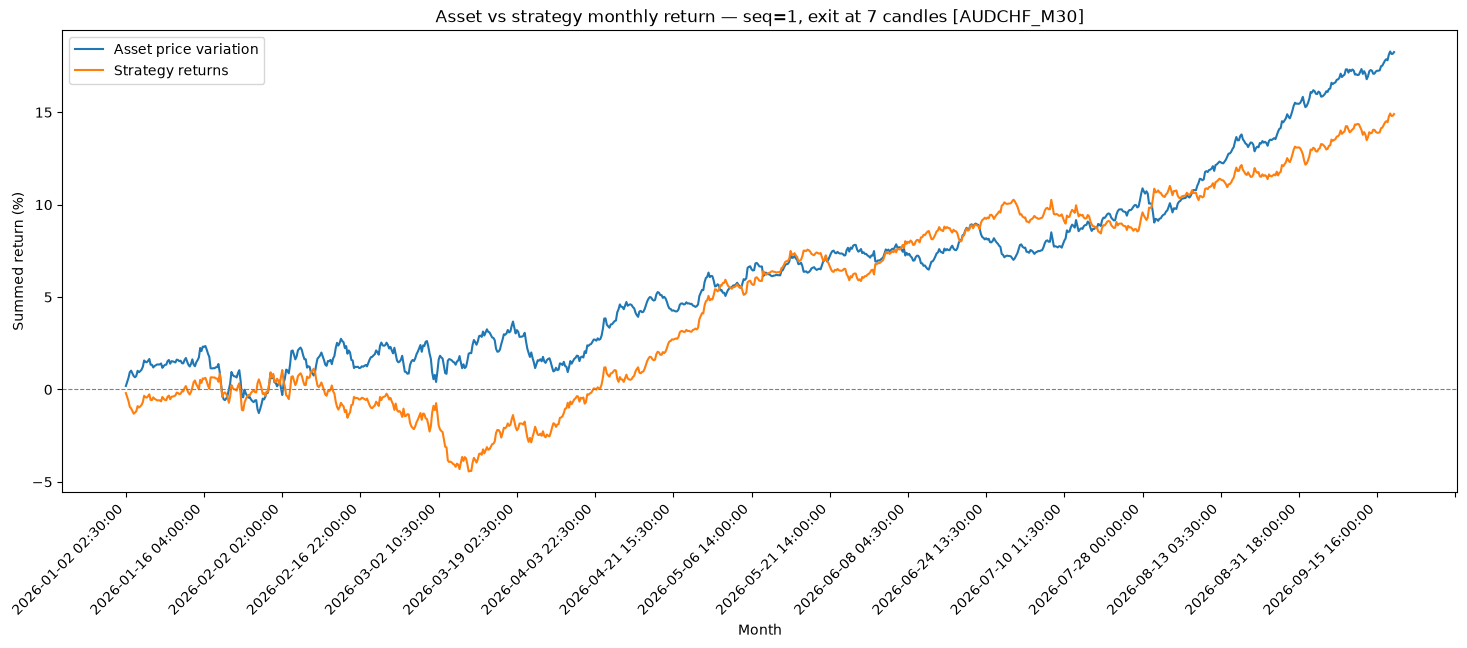

In [145]:
aggregated_df = calculate_returns(period_from, period_to, grouping=group_data)

if group_data:
    x_axis = 'month'
else:
    x_axis = 'time'

fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(aggregated_df[x_axis], aggregated_df['asset_variation'], label='Asset price variation')
ax.plot(aggregated_df[x_axis], aggregated_df['cumulative_return'], label='Strategy returns')
# ax.plot(aggregated_df['month'], aggregated_df['asset_variation'], marker='o', label='Asset price variation')
# ax.plot(aggregated_df['month'], aggregated_df['cumulative_return'], marker='o', label='Strategy returns')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Month')
ax.set_ylabel('Summed return (%)')
ax.set_title(f'Asset vs strategy monthly return — seq={num_seq}, exit at {num_candles_exit} candles [{asset}_{tf}]')
ax.legend()
ax.xaxis.set_major_locator(plt.MaxNLocator(20))
plt.xticks(rotation=45, ha='right')
# plt.tight_layout()
plt.show()

# Obter cesta de ativos

In [146]:
# data = {}
# for symbol in SYMBOLS:
#     data[symbol] = {}
#     for tf_label, tf in TIMEFRAMES.items():
#         data[symbol][tf_label] = mt5_data.get_rates_df(symbol, tf, START, END)

# data["EURUSD"]["H1"].head()

In [147]:
# data["EURUSD"]["M5"].describe()

## Gráfico de fechamento (por par, timeframe D1)

In [148]:
# fig, ax = plt.subplots(figsize=(10, 5))
# for symbol in SYMBOLS:
#     df = data[symbol]["D1"]
#     ax.plot(df["time"], df["close"], label=symbol)
# ax.legend()
# ax.set_title("Fechamento diário")
# plt.show()

In [149]:
# mt5_data.shutdown()